# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv("cleaned_airplane_data.csv")

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
df["Plane.type"] = np.where(df["total_passengers"] >= 20 ,"larger airplane","smaller airplane")
smaller_df = df[df["Plane.type"] == "smaller airplane"]
larger_df = df[df["Plane.type"] == "larger airplane"]


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

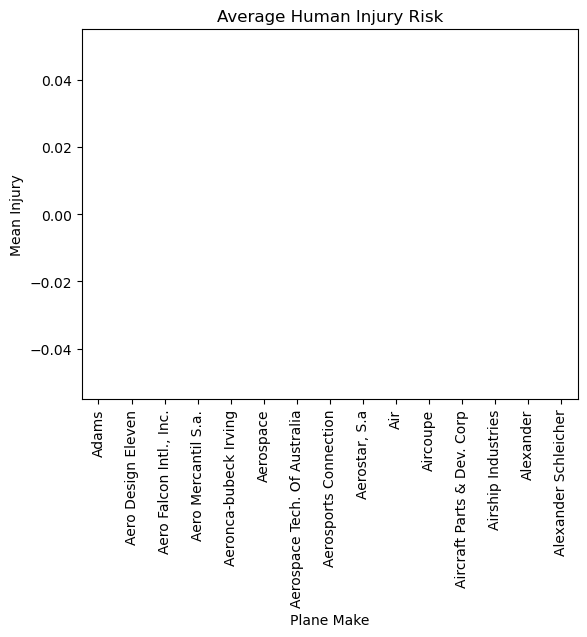

In [5]:
human_risk = df.groupby(df["Make"])["likelihood_serious_fatal"].mean().nsmallest(15)
human_risk.plot(kind="bar",title="Average Human Injury Risk",xlabel="Plane Make",ylabel="Mean Injury")
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

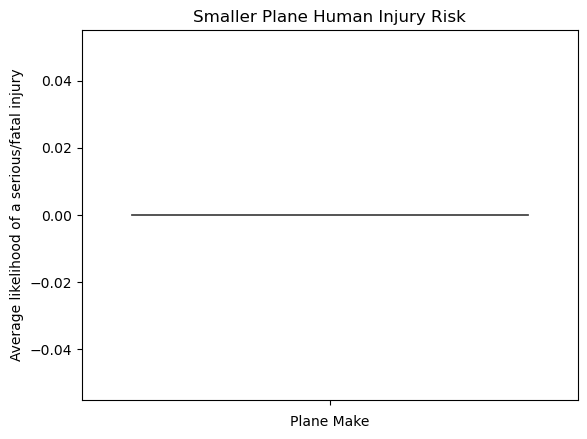

In [6]:
smaller_injury =smaller_df.groupby(["Make"])["likelihood_serious_fatal"].mean().nsmallest(10)
sns.violinplot(data=smaller_injury)
plt.title("Smaller Plane Human Injury Risk")
plt.xlabel("Plane Make")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

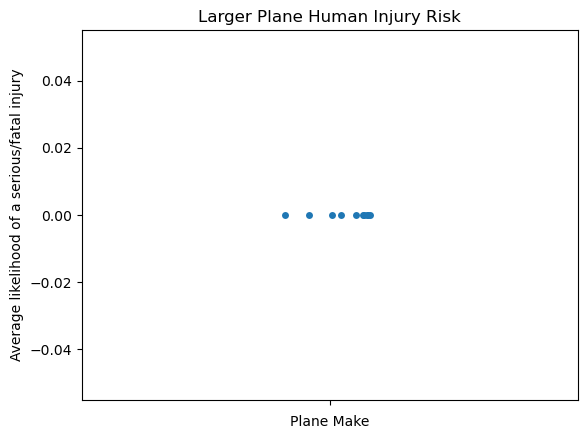

In [7]:
larger_injury = larger_df.groupby(["Make"])["likelihood_serious_fatal"].mean().nsmallest(10)
sns.stripplot(data=larger_injury)
plt.title("Larger Plane Human Injury Risk")
plt.xlabel("Plane Make")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [8]:
destruction_rate = df.groupby(["Make"])["Destroyed?"].mean().nsmallest(15)

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [9]:
"""
The analysis of 2029 planes suggest that there 
is no risk of injury and total destruction as 
indicated in the three plots demostrating a 
mean of 0 likelihood of fatal or serious
injury in the larger and smaller airplanes cases.
However, this is not an accurate representation of
the entire dataset that has a higher average likelihood
of serious or fatal injuries and destruction rate 
arising from accidents.

"""

'\nThe analysis of 2029 planes suggest that there \nis no risk of injury and total destruction as \nindicated in the three plots demostrating a \nmean of 0 likelihood of fatal or serious\ninjury in the larger and smaller airplanes cases.\nHowever, this is not an accurate representation of\nthe entire dataset that has a higher average likelihood\nof serious or fatal injuries and destruction rate \narising from accidents.\n\n'

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

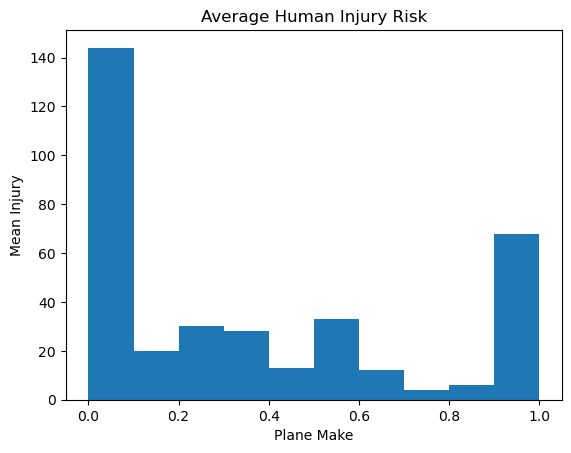

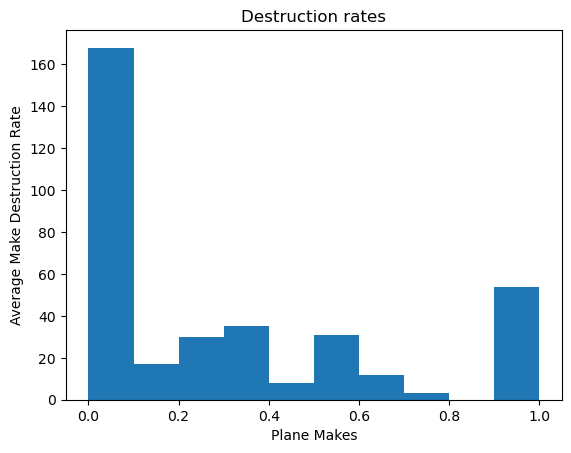

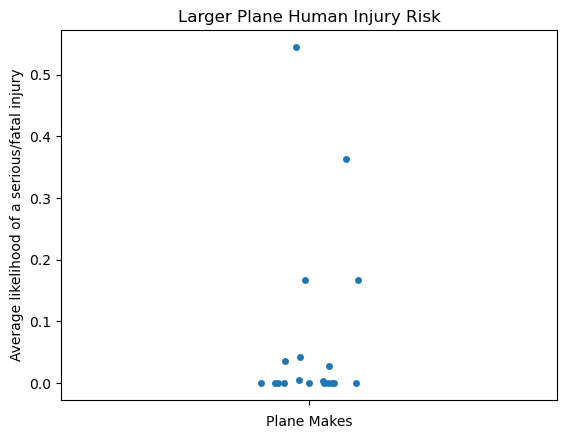

In [10]:
human_risk = df.groupby(df["Make"])["likelihood_serious_fatal"].mean()
human_risk.plot(kind="hist",title="Average Human Injury Risk",xlabel="Plane Make",ylabel="Mean Injury")
plt.show()
destruction_rate = df.groupby(["Make"])["Destroyed?"].mean().sort_values()
destruction_rate.plot(kind="hist",title="Destruction rates",xlabel="Plane Makes",ylabel="Average Make Destruction Rate")
plt.show()
larger_injury = larger_df.groupby(["Make"])["likelihood_serious_fatal"].mean()
sns.stripplot(data=larger_injury)
plt.title("Larger Plane Human Injury Risk")
plt.xlabel("Plane Makes")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

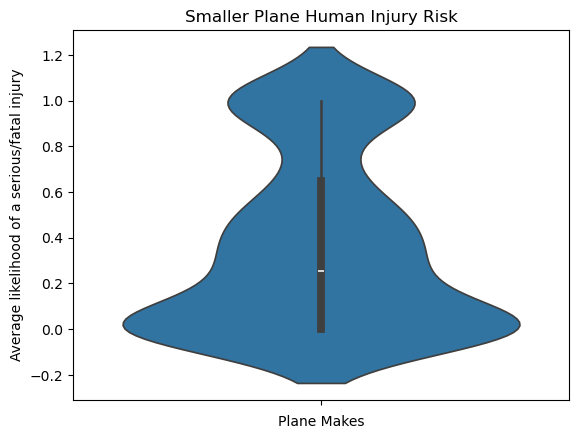

In [11]:
smaller_injury =smaller_df.groupby(["Make"])["likelihood_serious_fatal"].mean()
sns.violinplot(data=smaller_injury)
plt.title("Smaller Plane Human Injury Risk")
plt.xlabel("Plane Makes")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [12]:
""" 
The risk of serious or fatal injuries from airplane
accidents is low as indicated in the right skew in
the histogram of serious/fatal injuries arising from injuries.
The striplot of larger plane average serious or fatal
injuries communicates the same with majority of plane
makes involved in accidents having a low mean of 
serious/fatal injuries.
The same relationship is observed in smaller planes
with majority of the smaller plane makes displaying
a lower mean likelihood of serious or fatal injuries.
"""

' \nThe risk of serious or fatal injuries from airplane\naccidents is low as indicated in the right skew in\nthe histogram of serious/fatal injuries arising from injuries.\nThe striplot of larger plane average serious or fatal\ninjuries communicates the same with majority of plane\nmakes involved in accidents having a low mean of \nserious/fatal injuries.\nThe same relationship is observed in smaller planes\nwith majority of the smaller plane makes displaying\na lower mean likelihood of serious or fatal injuries.\n'

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

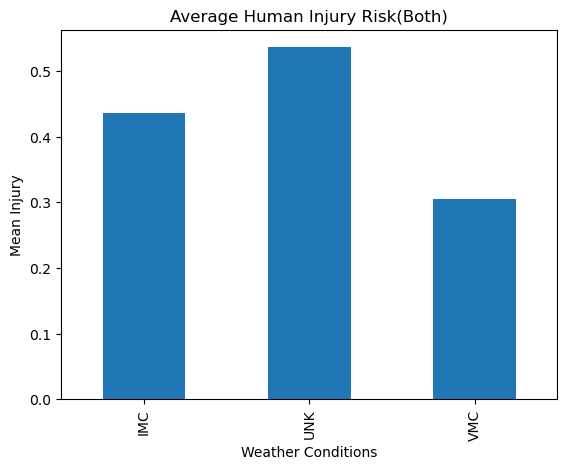

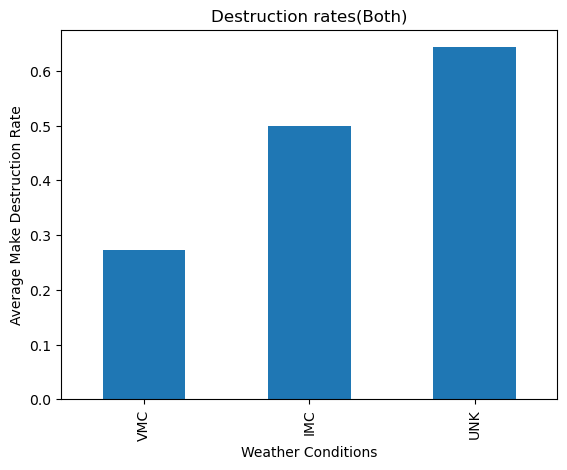

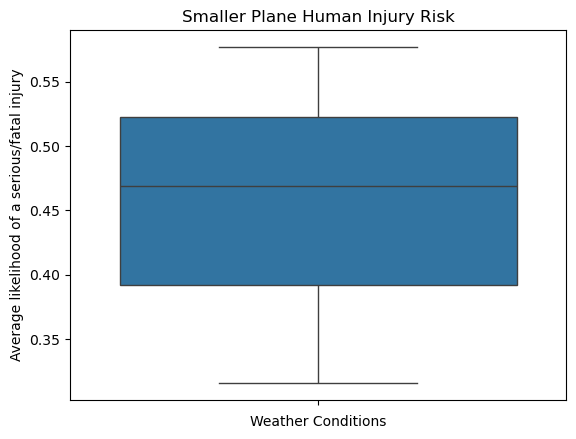

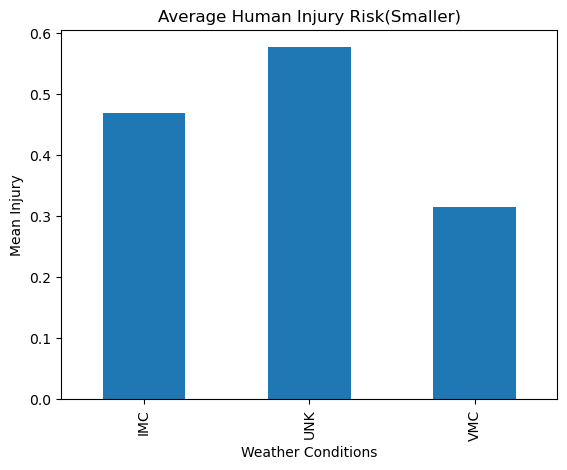

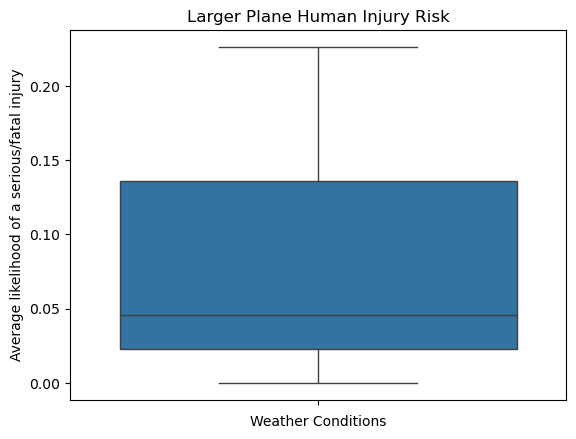

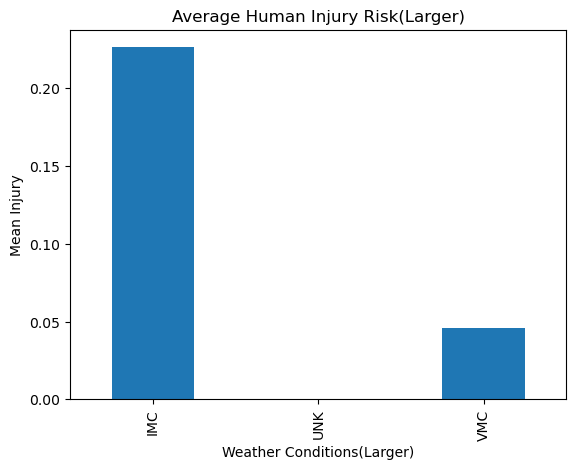

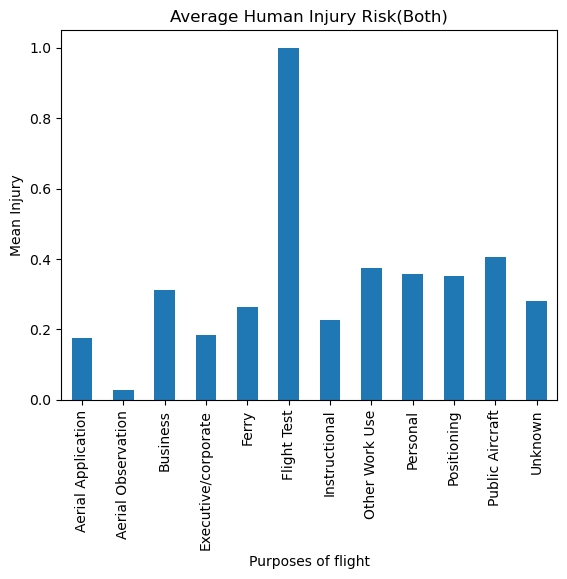

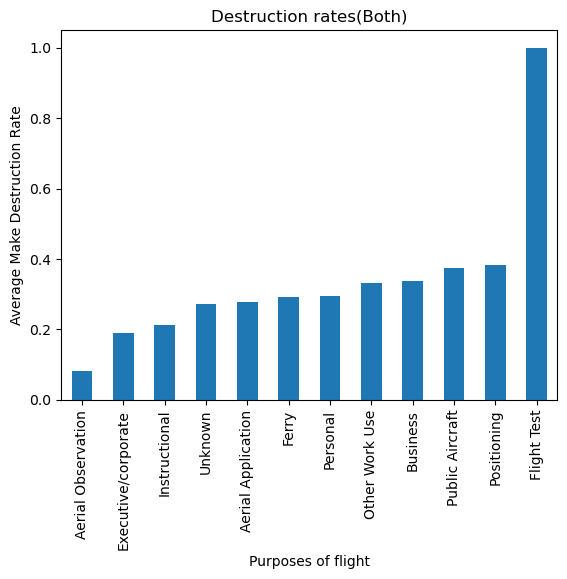

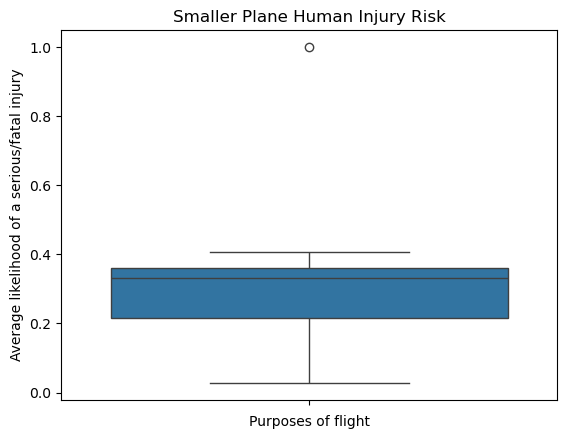

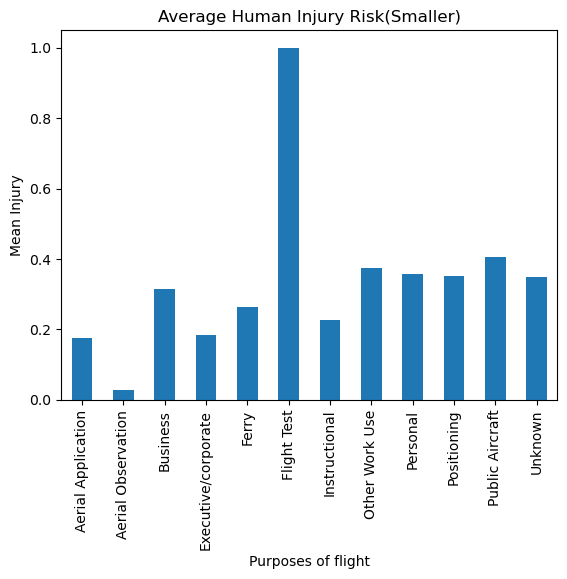

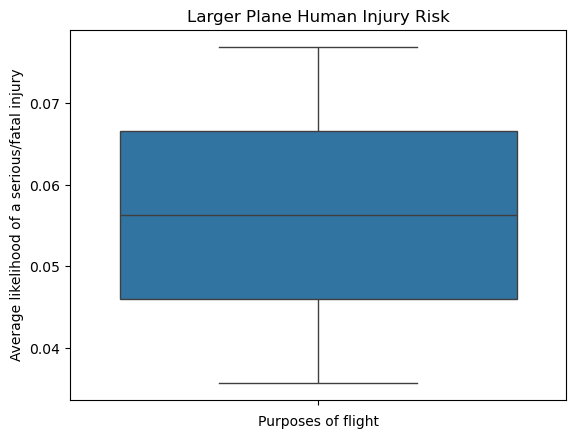

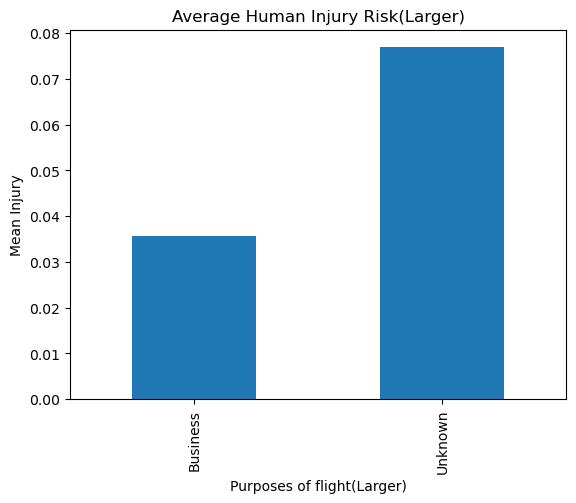

' \nThe two bar graphs both indicate that weather conditions have\nmoderate impact on both risk of serious/fatal injuries and\ndestruction of airplanes. The UNK weather conditions have the\nhighest cause in injury and desctruction rates. This weather condition\nappears unexpectedly and is a major cause of accidents especially for\npilots lacking IFR flights who may experience a loss of spatial awareness\nleading to inability to track the planes altitude. \n\nWhen further inspected by smaller and larger plane types as seen \nin the boxplots, the smaller planes are more impacted \nby adverse weather conditions than the larger planes,\nwith injury and destructions rates being affected moderately in smallerplanes.\nWhereas, the large planes injury and dextruction rates demonstrate \nvery low change caused by weather conditions. The higher injury and destruction \nrates in the smaller planes can be reduced by encouraging smaller plane pilots\nto take IFR training with incentives such as low

In [ ]:
"""
In order to analyse whether there is a relationship
between the weather condition and destruction rate as
well as serious or fatal injury rates, their respective mean
will be used.
"""
human_risk = df.groupby(df["Weather.Condition"])["likelihood_serious_fatal"].mean()
human_risk.plot(kind="bar",title="Average Human Injury Risk(Both)",xlabel="Weather Conditions",ylabel="Mean Injury")
plt.show()
destruction_rate = df.groupby(["Weather.Condition"])["Destroyed?"].mean().sort_values()
destruction_rate.plot(kind="bar",title="Destruction rates(Both)",xlabel="Weather Conditions",ylabel="Average Make Destruction Rate")
plt.show()


smaller_injury =smaller_df.groupby(["Weather.Condition"])["likelihood_serious_fatal"].mean()
sns.boxplot(data=smaller_injury)
plt.title("Smaller Plane Human Injury Risk")
plt.xlabel("Weather Conditions")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()
smaller_injury.plot(kind="bar",title="Average Human Injury Risk(Smaller)",xlabel="Weather Conditions",ylabel="Mean Injury")
plt.show()
larger_injury = larger_df.groupby(["Weather.Condition"])["likelihood_serious_fatal"].mean()
sns.boxplot(data=larger_injury)
plt.title("Larger Plane Human Injury Risk")
plt.xlabel("Weather Conditions")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()
larger_injury.plot(kind="bar",title="Average Human Injury Risk(Larger)",xlabel="Weather Conditions(Larger)",ylabel="Mean Injury")
plt.show()

human_risk1 = df.groupby(df["Purpose.of.flight"])["likelihood_serious_fatal"].mean()
human_risk1.plot(kind="bar",title="Average Human Injury Risk(Both)",xlabel="Purposes of flight",ylabel="Mean Injury")
plt.show()
destruction_rate = df.groupby(["Purpose.of.flight"])["Destroyed?"].mean().sort_values()
destruction_rate.plot(kind="bar",title="Destruction rates(Both)",xlabel="Purposes of flight",ylabel="Average Make Destruction Rate")
plt.show()


smaller_injury1 =smaller_df.groupby(["Purpose.of.flight"])["likelihood_serious_fatal"].mean()
sns.boxplot(data=smaller_injury1)
plt.title("Smaller Plane Human Injury Risk")
plt.xlabel("Purposes of flight")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()
smaller_injury1.plot(kind="bar",title="Average Human Injury Risk(Smaller)",xlabel="Purposes of flight",ylabel="Mean Injury")
plt.show()
larger_injury1 = larger_df.groupby(["Purpose.of.flight"])["likelihood_serious_fatal"].mean()
sns.boxplot(data=larger_injury1)
plt.title("Larger Plane Human Injury Risk")
plt.xlabel("Purposes of flight")
plt.ylabel("Average likelihood of a serious/fatal injury")
plt.show()
larger_injury1.plot(kind="bar",title="Average Human Injury Risk(Larger)",xlabel="Purposes of flight(Larger)",ylabel="Mean Injury")
plt.show()

""" 
Weather Condition
The two bar graphs both indicate that weather conditions have
moderate impact on both risk of serious/fatal injuries and
destruction of airplanes. The UNK weather conditions have the
highest cause in injury and desctruction rates. This weather condition
appears unexpectedly and is a major cause of accidents especially for
pilots lacking IFR flights who may experience a loss of spatial awareness
leading to inability to track the planes altitude. 

When further inspected by smaller and larger plane types as seen 
in the boxplots, the smaller planes are more impacted 
by adverse weather conditions than the larger planes,
with injury and destructions rates being affected moderately in smallerplanes.
Whereas, the large planes injury and dextruction rates demonstrate 
very low change caused by weather conditions. The higher injury and destruction 
rates in the smaller planes can be reduced by encouraging smaller plane pilots
to take IFR training with incentives such as lower premiums for IFR trained pilots
resulting in better safety and insurance claims for destroyed planes.
"""
""" 
Purpose of flight
Generally speaking, the purposes of flight are not closely linked to destruction and injury
rates. However, there is an execption of "flight tests" being the purpose of flight that has a
very high injury and destruction rate. This is more prevalent in the smaller planes as evident in the
boxplots. In regard to the larger planes, the impact of purpose of flight on injury and destruction
rates is very low with the major cause being unkown. This will require further exploration to identify
the purpose of those flights.

The use of Certified Flight Instructors, thorough underwriting, risk data from previous makes and
endorsement from experts will aid in mitagating safety issues and reduce injury and destruction rates
during flight tests.
"""